# Риск и распределение инвестиций в стартапы: расчёт объёма инвестиций

---

# Цель:
- Написать модель машинного обучения для:
    - рассчёта оптимального объёма инвестиций в стартап;
    - выявление признаков, влияющих на объём инвестиций;
    - сохранение модели для дальнейшего использования (расчёт объёма инвестиций).

In [1]:
import os
import numpy as np
import warnings
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import itertools
plt.rcParams['figure.figsize'] = (8, 7)
%matplotlib inline
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('../data/processed/startup_investment_dataset+rejected_status.csv')

In [3]:
df.head()

,startup_stage,industry,region,requested_amount,pre_money_valuation,team_size,founders_experience_years,annual_revenue,market_size_estimate,investment_amount,is_rejected
0,Pre-Seed,ClimateTech,US,1.381327e+06,7.223187e+06,9,3,0.000000,6.039942e+06,0.000000e+00,1
1,Series B,HealthTech,US,7.784759e+06,3.049307e+07,13,8,96087.461835,6.886030e+07,7.203092e+06,0
2,Pre-Seed,HealthTech,LATAM,1.306439e+06,1.022702e+07,5,3,0.000000,1.896208e+07,0.000000e+00,1
3,Idea,E-commerce,US,8.840830e+05,4.531614e+06,3,2,0.000000,7.717272e+06,0.000000e+00,1
4,Series B,E-commerce,US,1.608484e+07,5.189190e+07,10,7,133652.729965,1.415670e+07,1.672645e+07,0


In [4]:
df = df[df['is_rejected'] == 0].drop(columns=['is_rejected', 'market_size_estimate'])
print(f'Общая длина: {len(df)} стартапов')
df.head()

Общая длина: 1948 стартапов


,startup_stage,industry,region,requested_amount,pre_money_valuation,team_size,founders_experience_years,annual_revenue,investment_amount
1,Series B,HealthTech,US,7.784759e+06,3.049307e+07,13,8,9.608746e+04,7.203092e+06
4,Series B,E-commerce,US,1.608484e+07,5.189190e+07,10,7,1.336527e+05,1.672645e+07
6,Seed,AI/SaaS,Europe,2.492487e+06,1.805700e+07,8,3,1.760057e+05,1.598191e+06
7,Series A,FinTech,US,7.464134e+06,3.169615e+07,11,5,1.219577e+06,4.706876e+06
8,Series A,AI/SaaS,US,3.152825e+06,2.375383e+07,9,2,1.266550e+05,2.755136e+06


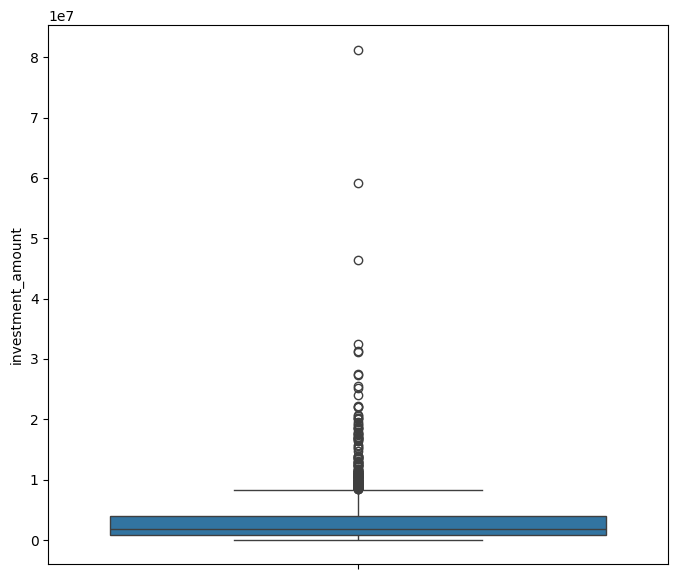

In [5]:
sns.boxplot(y=df['investment_amount'])
plt.show()

In [6]:
# Избавление от выбросов
q_low = df['investment_amount'].quantile(0.01)
q_high = df['investment_amount'].quantile(0.95)

df = df[(df['investment_amount'] >= q_low) & (df['investment_amount'] <= q_high)]

print(f'Отобрано {len(df)} стартапов с объёмом инвестиций от ${int(q_low):,} до ${int(q_high):,}.')

Отобрано 1830 стартапов с объёмом инвестиций от $137,361 до $10,043,519.


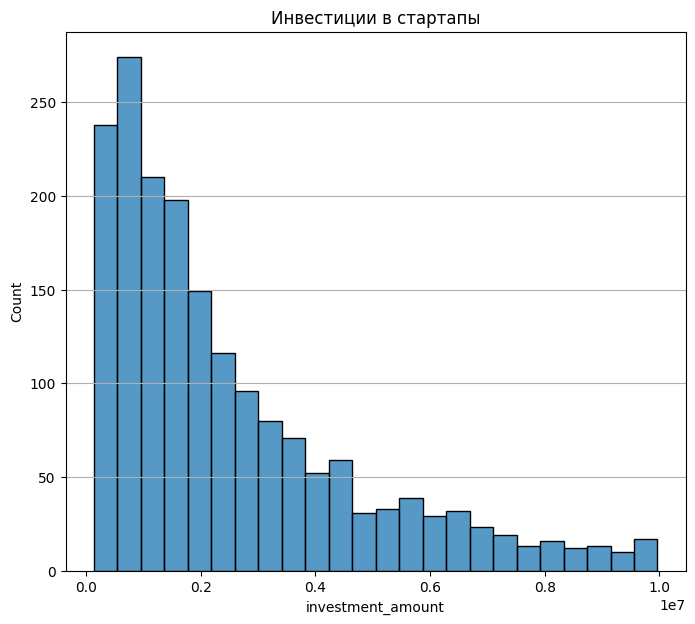

In [7]:
sns.histplot(data=df, x='investment_amount')
plt.title('Инвестиции в стартапы')
plt.grid(axis='y')
plt.show()

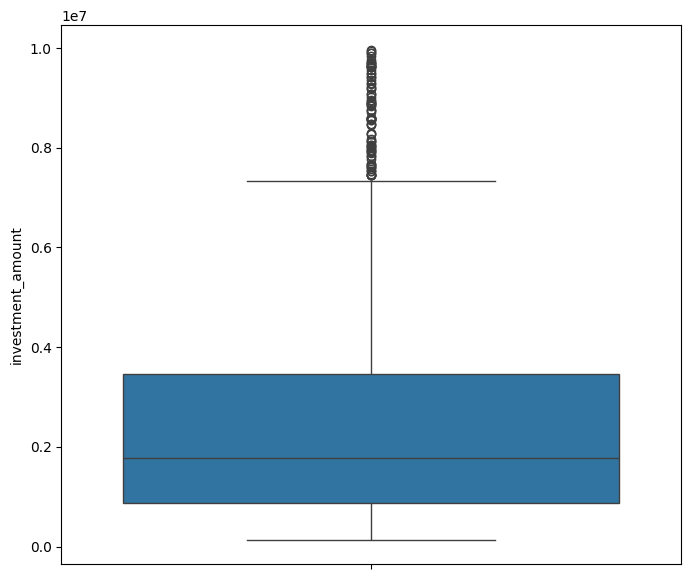

In [8]:
sns.boxplot(y=df['investment_amount'])
plt.show()

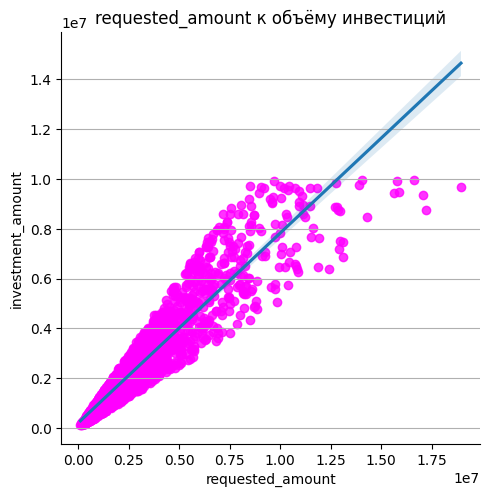

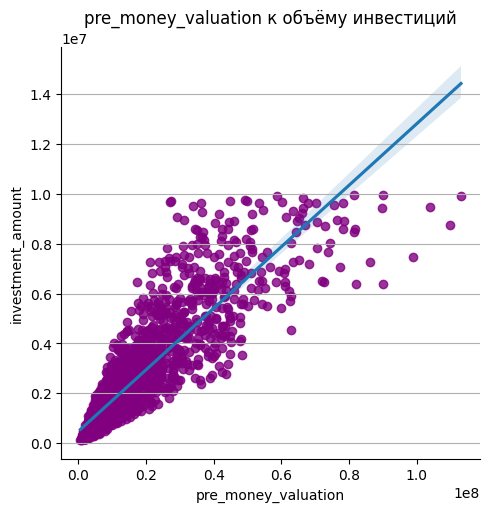

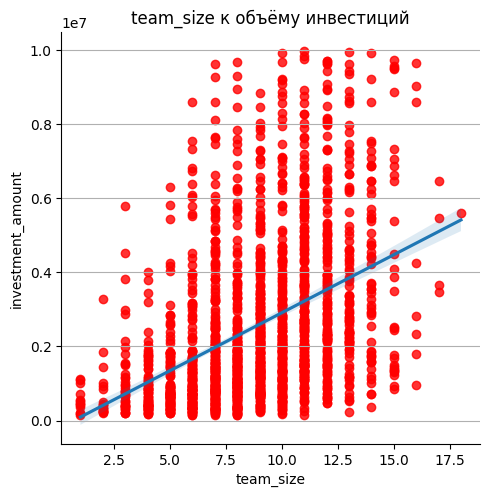

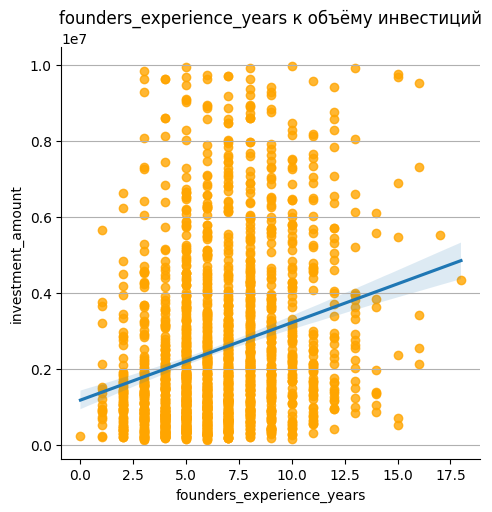

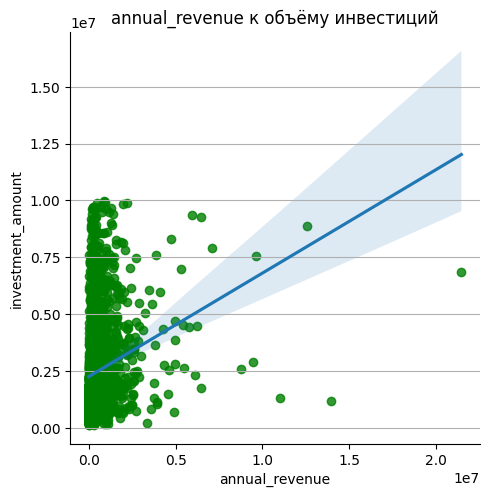

In [9]:
color_map = {
    'requested_amount': 'magenta',
    'team_size': 'red',
    'annual_revenue': 'green',
    'pre_money_valuation': 'purple',
    'founders_experience_years': 'orange'
}

for feature in df.select_dtypes(include=['int64', 'float64']).columns:
    if feature != 'investment_amount':
        sns.lmplot(
            data=df,
            x=feature,
            y='investment_amount',
            scatter_kws={'color': color_map.get(feature, 'gray')},
        )
        plt.grid(axis='y')
        plt.title(f'{feature} к объёму инвестиций')
        plt.show()

# Моделирование

In [10]:
import mlflow
import joblib

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from sklearn.cluster import KMeans

from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

## Feature engineering

Добавление новых признаков для лучшего обучения модели:

- Добавление отношений денежных признаков;
- Добавление производных признаков от команды;
- Бизнес-признаки;
- Логарифмирование денежных и остальных числовых признаков;

In [11]:
def create_additional_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    
    eps = 1

    # --- Отношения денежных признаков ---
    df['requested_to_valuation'] = (df['requested_amount'] / (df['pre_money_valuation'] + eps))
    df['revenue_to_valuation'] = (df['annual_revenue'] / (df['pre_money_valuation'] + eps))
    df['revenue_per_employee'] = (df['annual_revenue'] / (df['team_size'] + eps))

    # --- Команда ---
    df['experience_per_member'] = (df['founders_experience_years'] / (df['team_size'] + eps))
    df['team_maturity'] = (df['team_size'] * df['founders_experience_years'])

    # --- Бизнес-флаги ---
    df['early_stage'] = (df['startup_stage'].isin(['Idea', 'Pre-Seed']).astype(int))
    df['is_us_market'] = ((df['region'] == 'US').astype(int))

    # --- Логарифмы денежных признаков ---

    numeric_features = df.select_dtypes(include=['int64', 'float64'])

    for col in numeric_features:
        if col in df.columns:
            df[f'{col}_log'] = np.log1p(df[col])

    # Очистка проблем после деления
    df.replace([np.inf, -np.inf], np.nan, inplace=True)

    return df

In [12]:
df = create_additional_features(df)
df.head()

,startup_stage,industry,region,requested_amount,pre_money_valuation,team_size,founders_experience_years,annual_revenue,investment_amount,requested_to_valuation,...,founders_experience_years_log,annual_revenue_log,investment_amount_log,requested_to_valuation_log,revenue_to_valuation_log,revenue_per_employee_log,experience_per_member_log,team_maturity_log,early_stage_log,is_us_market_log
1,Series B,HealthTech,US,7.784759e+06,3.049307e+07,13,8,9.608746e+04,7.203092e+06,0.255296,...,2.197225,11.473025,15.790021,0.227371,0.003146,8.834102,0.451985,4.653960,0.0,0.693147
6,Seed,AI/SaaS,Europe,2.492487e+06,1.805700e+07,8,3,1.760057e+05,1.598191e+06,0.138034,...,1.386294,12.078277,14.284384,0.129303,0.009700,9.881098,0.287682,3.218876,0.0,0.000000
7,Series A,FinTech,US,7.464134e+06,3.169615e+07,11,5,1.219577e+06,4.706876e+06,0.235490,...,1.791759,14.014015,15.364535,0.211468,0.037755,11.529118,0.348307,4.025352,0.0,0.693147
8,Series A,AI/SaaS,US,3.152825e+06,2.375383e+07,9,2,1.266550e+05,2.755136e+06,0.132729,...,1.098612,11.749230,14.828978,0.124630,0.005318,9.446716,0.182322,2.944439,0.0,0.693147
9,Seed,FinTech,US,2.722484e+06,1.256703e+07,8,8,3.605893e+05,1.459347e+06,0.216637,...,2.197225,12.795498,14.193501,0.196091,0.028289,10.598295,0.635989,4.174387,0.0,0.693147


In [13]:
# Логарифмирование целевой переменной
df['investment_amount_log'] = np.log1p(df['investment_amount'])

target = 'investment_amount_log'

# Кластеризация стартапов

- В распределении объёмов инвестиций наблюдается сильный скос вправо, что говорит о наличии отлично высоких объёмах, следовательно модель не сможет стабильно работать на всей выборке
- Кластеризация стартапов поможет разбить их на группы, на каждую из которых можно создать уникальную регрессионную модель.
- Идея кластеризации заключается в разделении стартапов на сегменты: __дешёвые__, __средние__ и ___дорогие__, при том __без использования целевой переменной__, поскольку кластер будет являться __прокси-признаком__, вызывающим:
    - Утечку данных;
    - Невозможность присвоить кластер при оценке новых стартапов.

В качестве признаков для сегментации используются:

- `requested_amount` — запрошенный объём инвестиций;
- `pre_money_valuation` — предварительная оценка стартапа;
- `annual_revenue` — существующая годовая выручка стартапа;
- `team_size` — количество сотрудников/участников;
- `founders_experience_years` — опыт сотрудников/участников.

In [14]:
cluster_preprocessor = Pipeline(steps=[
    ('scaler', StandardScaler())
])

cluster_preprocessor

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [15]:
cluster_features = [
    'requested_amount',
    'pre_money_valuation',
    'annual_revenue',
    'team_size',
]

kmeans = Pipeline(steps=[
    ('preprocessor', cluster_preprocessor),
    ('kmeans', KMeans(n_clusters=4, random_state=42))
])

kmeans.fit(df[cluster_features])

clusters = kmeans.predict(
    df[cluster_features]
)

df['cluster'] = clusters
df.head()

,startup_stage,industry,region,requested_amount,pre_money_valuation,team_size,founders_experience_years,annual_revenue,investment_amount,requested_to_valuation,...,annual_revenue_log,investment_amount_log,requested_to_valuation_log,revenue_to_valuation_log,revenue_per_employee_log,experience_per_member_log,team_maturity_log,early_stage_log,is_us_market_log,cluster
1,Series B,HealthTech,US,7.784759e+06,3.049307e+07,13,8,9.608746e+04,7.203092e+06,0.255296,...,11.473025,15.790021,0.227371,0.003146,8.834102,0.451985,4.653960,0.0,0.693147,0
6,Seed,AI/SaaS,Europe,2.492487e+06,1.805700e+07,8,3,1.760057e+05,1.598191e+06,0.138034,...,12.078277,14.284384,0.129303,0.009700,9.881098,0.287682,3.218876,0.0,0.000000,1
7,Series A,FinTech,US,7.464134e+06,3.169615e+07,11,5,1.219577e+06,4.706876e+06,0.235490,...,14.014015,15.364535,0.211468,0.037755,11.529118,0.348307,4.025352,0.0,0.693147,0
8,Series A,AI/SaaS,US,3.152825e+06,2.375383e+07,9,2,1.266550e+05,2.755136e+06,0.132729,...,11.749230,14.828978,0.124630,0.005318,9.446716,0.182322,2.944439,0.0,0.693147,1
9,Seed,FinTech,US,2.722484e+06,1.256703e+07,8,8,3.605893e+05,1.459347e+06,0.216637,...,12.795498,14.193501,0.196091,0.028289,10.598295,0.635989,4.174387,0.0,0.693147,3


In [16]:
display(df[df.cluster==2][[
        'startup_stage',
        'requested_amount',
        'pre_money_valuation',
        'annual_revenue',
        'team_size',
        'investment_amount'
    ]].head(15)
)

,startup_stage,requested_amount,pre_money_valuation,annual_revenue,team_size,investment_amount
87,Series A,1.288858e+06,9.435831e+06,4.908132e+06,14,7.243237e+05
172,Series B,7.238961e+06,5.097226e+07,2.147011e+07,10,6.839447e+06
240,Series A,2.442764e+06,1.199705e+07,4.329527e+06,9,2.789293e+06
298,Series B,6.494890e+06,4.220368e+07,4.279628e+06,13,4.346944e+06
379,Series B,7.204680e+06,3.107630e+07,9.617092e+06,14,7.538984e+06
634,Series A,7.142489e+06,3.506903e+07,5.403820e+06,7,4.523112e+06
654,Series A,9.665539e+06,3.638530e+07,6.482310e+06,7,9.272808e+06
687,Series A,2.635845e+06,1.879836e+07,6.137079e+06,13,2.345120e+06
818,Series B,2.373313e+06,1.724016e+07,1.099183e+07,10,1.306727e+06
1055,Series B,1.273084e+07,7.041236e+07,1.259119e+07,15,8.867364e+06


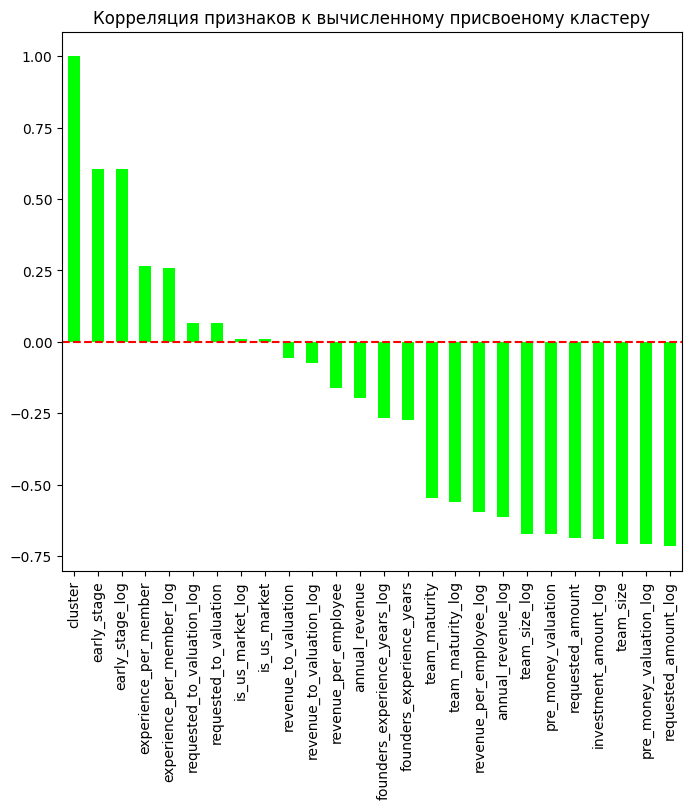

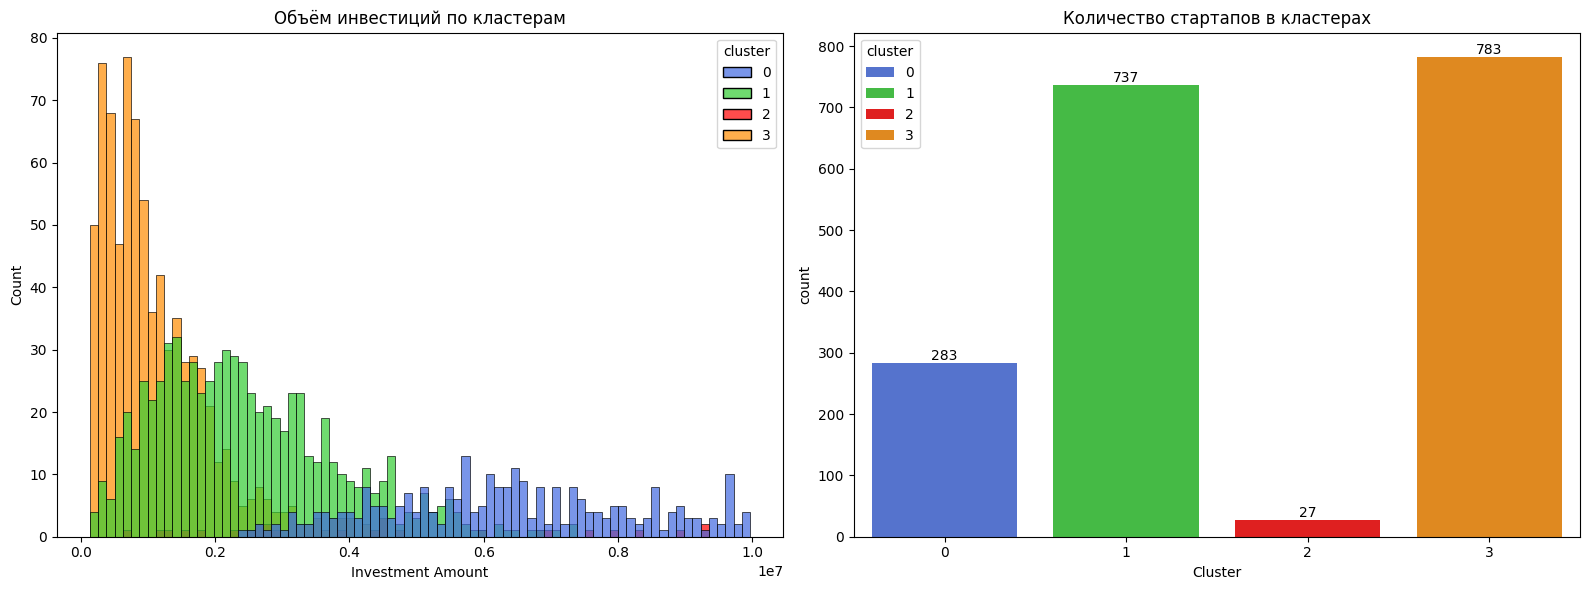

In [17]:
ax = (
    df.drop(columns=['investment_amount'])
        .corr(numeric_only=True)['cluster']
        .sort_values(ascending=False).plot(kind='bar', color='lime')
     )
plt.axhline(y=0, linestyle='--', c='red')
plt.title('Корреляция признаков к вычисленному присвоеному кластеру')
plt.show()

# ---------------------------------

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 6))

# Clusters palette
palette = {
    0: "royalblue",
    1: "limegreen",
    2: "red",       # обязательно красный
    3: "darkorange"
}

df_sorted = df.sort_values(by='investment_amount', ascending=True)

sns.histplot(data=df_sorted, x='investment_amount', hue='cluster', palette=palette, alpha=.7, ax=axes[0], bins=80)
axes[0].set_title('Объём инвестиций по кластерам')
axes[0].set_xlabel('Investment Amount')

sns.countplot(data=df, x='cluster', hue='cluster', palette=palette, ax=axes[1])
# Подписи над столбцами
for container in axes[1].containers:
    axes[1].bar_label(container)
axes[1].set_title('Количество стартапов в кластерах')
axes[1].set_xlabel('Cluster')
plt.tight_layout()

plt.show()

In [18]:
### print('Процентное соотношение сегментов:\n', df['cluster'].value_counts(normalize=True).sort_index() * 100)

cluster_stats = df.groupby('cluster').mean(numeric_only=True).sort_values(by='requested_amount')
display(cluster_stats)

,requested_amount,pre_money_valuation,team_size,founders_experience_years,annual_revenue,investment_amount,requested_to_valuation,revenue_to_valuation,revenue_per_employee,experience_per_member,...,founders_experience_years_log,annual_revenue_log,investment_amount_log,requested_to_valuation_log,revenue_to_valuation_log,revenue_per_employee_log,experience_per_member_log,team_maturity_log,early_stage_log,is_us_market_log
cluster,,,,,,,,,,,,,,,,,,,,,
3,1.328832e+06,7.027602e+06,6.196679,5.696041,1.711883e+05,1.118852e+06,0.200121,0.025282,22460.969191,0.858510,...,1.832053,5.021170,13.674531,0.181310,0.023769,4.193187,0.591494,3.437911,0.416951,0.318688
1,2.871011e+06,1.503571e+07,10.580733,6.982361,6.629229e+05,2.457649e+06,0.199885,0.062478,58850.251217,0.612205,...,2.015845,12.483183,14.541250,0.181127,0.056017,10.139374,0.466600,4.219652,0.027274,0.298138
2,5.732619e+06,3.148084e+07,11.185185,7.333333,7.171226e+06,4.538247e+06,0.184798,0.329926,610706.817031,0.605862,...,2.035616,15.688896,15.123216,0.168658,0.261888,13.207060,0.459982,4.288248,0.000000,0.282393
0,7.879639e+06,4.494055e+07,10.756184,7.586572,7.161906e+05,6.322830e+06,0.183886,0.017137,62929.286089,0.669976,...,2.092818,12.952311,15.612786,0.167810,0.016869,10.538501,0.500140,4.306311,0.007348,0.325755


### > Анализ 2-го кластера

In [19]:
print(df['cluster'].value_counts())
print(df['cluster'].value_counts(normalize=True)*100)

cluster
3    783
1    737
0    283
2     27
Name: count, dtype: int64
cluster
3    42.786885
1    40.273224
0    15.464481
2     1.475410
Name: proportion, dtype: float64


In [20]:
df[df['cluster'] == 2].head(7)

,startup_stage,industry,region,requested_amount,pre_money_valuation,team_size,founders_experience_years,annual_revenue,investment_amount,requested_to_valuation,...,annual_revenue_log,investment_amount_log,requested_to_valuation_log,revenue_to_valuation_log,revenue_per_employee_log,experience_per_member_log,team_maturity_log,early_stage_log,is_us_market_log,cluster
87,Series A,EdTech,US,1.288858e+06,9.435831e+06,14,4,4.908132e+06,7.243237e+05,0.136592,...,15.406404,13.492995,0.128034,0.418815,12.698357,0.236389,4.043051,0.0,0.693147,2
172,Series B,HealthTech,Asia,7.238961e+06,5.097226e+07,10,4,2.147011e+07,6.839447e+06,0.142018,...,16.882172,15.738218,0.132797,0.351510,14.484277,0.310155,3.713572,0.0,0.000000,2
240,Series A,E-commerce,US,2.442764e+06,1.199705e+07,9,7,4.329527e+06,2.789293e+06,0.203614,...,15.280969,14.841299,0.185328,0.308133,12.978386,0.530628,4.158883,0.0,0.693147,2
298,Series B,HealthTech,Europe,6.494890e+06,4.220368e+07,13,18,4.279628e+06,4.346944e+06,0.153894,...,15.269377,15.284984,0.143142,0.096586,12.630323,0.826679,5.459586,0.0,0.000000,2
379,Series B,AI/SaaS,Europe,7.204680e+06,3.107630e+07,14,11,9.617092e+06,7.538984e+06,0.231838,...,16.079053,15.835598,0.208508,0.269620,13.371004,0.550046,5.043425,0.0,0.000000,2
634,Series A,E-commerce,US,7.142489e+06,3.506903e+07,7,5,5.403820e+06,4.523112e+06,0.203669,...,15.502617,15.324711,0.185375,0.143313,13.423177,0.485508,3.583519,0.0,0.693147,2
654,Series A,HealthTech,Asia,9.665539e+06,3.638530e+07,7,3,6.482310e+06,9.272808e+06,0.265644,...,15.684588,16.042597,0.235581,0.163952,13.605147,0.318454,3.091042,0.0,0.000000,2


In [21]:
try:
    joblib.dump(kmeans, '../src/models/models_to_use/clusteriser.joblib')
    print('Модель кластеризации сохранена.')
except Exception as e:
    print(f'Не удалось сохранить препроцессор/модель кластеризации.\n{e}')

Модель кластеризации сохранена.


---

## Кластеризация стартапов

Для дополнительной сегментации стартапов была проведена кластеризация методом K-Means. Целью являлось выделение групп компаний со схожими финансовыми и организационными характеристиками для дальнейшего использования в инвестиционном пайплайне.

Кластеризация позволяет разделить стартапы на группы со схожим профилем риска и масштаба, а затем использовать специализированные модели регрессии для каждого сегмента отдельно.

### Использованные признаки

Для обучения использовались признаки, отражающие зрелость компании и масштаб бизнеса:

- `requested_amount`
- `pre_money_valuation`
- `annual_revenue`
- `team_size`
- `founders_experience_years`

При построении модели не использовались:

- `investment_amount`

Это исключает утечку данных (data leakage), поскольку будущий объём инвестиций не участвует в формировании сегментов.

---

## Распределение стартапов по кластерам

| Кластер | Количество | Доля |
|----------|------------:|------:|
| 3 | 783 | 42.8% |
| 1 | 737 | 40.3% |
| 0 | 283 | 15.5% |
| 2 | 27 | 1.5% |

Основную часть выборки составляют два массовых сегмента: ранние и зрелые стартапы. Также были обнаружены более крупные компании и небольшой специализированный сегмент высокодоходных стартапов.

---

## Средние значения ключевых признаков

| Кластер | Requested Amount | Pre-money Valuation | Annual Revenue | Investment Amount |
|----------|----------------:|--------------------:|----------------:|------------------:|
| 3 | 1.33M | 7.03M | 0.17M | 1.12M |
| 1 | 2.87M | 15.04M | 0.66M | 2.46M |
| 0 | 7.88M | 44.94M | 0.72M | 6.32M |
| 2 | 5.73M | 31.48M | 7.17M | 4.54M |

Наблюдается закономерное увеличение размеров компаний:

```text
Cluster 3 → Cluster 1 → Cluster 0

ранние → зрелые → крупные
```

Однако был обнаружен дополнительный сегмент:

```text
Cluster 2

высокодоходные scale-up компании
```

---

## Интерпретация кластеров

### Cluster 3 — Early Stage Startups

Наиболее ранний сегмент.

Характеристики:

- высокая доля Idea и Pre-Seed
- небольшие команды
- низкий объём выручки
- минимальные объёмы инвестиций
- высокая неопределённость

Этот кластер соответствует типичным ранним стартапам, находящимся на стадии поиска продукта и рынка.

---

### Cluster 1 — Mature Startups

Основной сегмент выборки.

Характеристики:

- преобладают стадии Seed и Series A
- сформированные команды
- умеренные показатели оценки
- средний инвестиционный объём

Представляет типичный венчурный рынок.

---

### Cluster 0 — Large Investment Startups

Крупные инвестиционные проекты.

Характеристики:

- высокие оценки компаний
- крупные команды
- значительные инвестиционные запросы
- поздние стадии развития

Данный сегмент соответствует стартапам, требующим повышенного объёма капитала и более серьёзной оценки рисков.

---

### Cluster 2 — High-Revenue Scale-Up Startups

Наиболее редкий сегмент (~1.5%).

Особенность данного кластера — аномально высокий объём выручки:

- Annual Revenue ≈ 7.17M
- преобладают стадии Series A / Series B
- опытные команды
- высокий уровень зрелости бизнеса

Несмотря на относительно небольшой размер сегмента, алгоритм K-Means выделил данные компании отдельно.

Вероятная интерпретация:

это не выбросы, а специализированный класс зрелых компаний, уже имеющих существенную выручку и находящихся на стадии масштабирования бизнеса (scale-up).

---

## Вывод

Кластеризация выявила устойчивую структуру рынка стартапов и выделила четыре различных сегмента компаний:

- ранние стартапы
- зрелые компании
- крупные инвестиционные проекты
- высокодоходные scale-up стартапы

Полученная сегментация может использоваться как дополнительный этап инвестиционного пайплайна:

```text
Startup Features
        ↓
Cluster Prediction
        ↓
Cluster-specific Regressor
        ↓
Investment Amount Prediction
```

Такой подход позволяет строить специализированные модели под разные типы компаний и потенциально снижать ошибку прогнозирования инвестиционного объёма.

# Регрессия

Распределение объёма инвестиций имеет выраженную положительную асимметрию: наблюдается длинный хвост крупных сделок. Это создаёт проблему дисбаланса — модели начинают сильнее оптимизироваться под большие инвестиции, ухудшая качество прогнозирования для основной части выборки.

Для снижения влияния перекоса применялось логарифмирование целевой переменной:

```python
investment_amount_log = np.log1p(investment_amount)
```

В качестве функции оптимизации используется **корень из среднеквадратичной ошибки (RMSE)**, поскольку данная метрика чувствительна к большим отклонениям и позволяет сильнее штрафовать крупные ошибки.

Основной метрикой оценки качества выбрана **MAPE (Mean Absolute Percentage Error)**, поскольку она показывает среднюю относительную ошибку прогноза и лучше интерпретируется с бизнес-точки зрения.

Дополнительно анализируются:

- RMSE
- MAE
- R^2

Учитывая:

- высокий уровень шума;
- табличный характер данных;
- наличие нелинейных зависимостей;
- ограниченный объём выборки;

для валидации были выбраны следующие алгоритмы:

- RandomForestRegressor
- GradientBoostingRegressor
- XGBoostRegressor
- LightGBMRegressor

Линейные модели и нейросетевые архитектуры не были выбраны как основные кандидаты, поскольку предварительные эксперименты показали их меньшую устойчивость на данной задаче.

## Разбиение и преобразование данных

In [22]:
num_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
remove_cols = ['investment_amount', 'investment_amount_log', 'cluster']
cat_features = df.select_dtypes(include=['object']).columns.tolist()

num_features = [col for col in num_features if col not in remove_cols]

print(f'Числовые признаки: {num_features}')
print(f'Категориальные признаки: {cat_features}')

Числовые признаки: ['requested_amount', 'pre_money_valuation', 'team_size', 'founders_experience_years', 'annual_revenue', 'requested_to_valuation', 'revenue_to_valuation', 'revenue_per_employee', 'experience_per_member', 'team_maturity', 'early_stage', 'is_us_market', 'requested_amount_log', 'pre_money_valuation_log', 'team_size_log', 'founders_experience_years_log', 'annual_revenue_log', 'requested_to_valuation_log', 'revenue_to_valuation_log', 'revenue_per_employee_log', 'experience_per_member_log', 'team_maturity_log', 'early_stage_log', 'is_us_market_log']
Категориальные признаки: ['startup_stage', 'industry', 'region']


# Обучение моделей машинного обучения

In [23]:
MODELS = {
    'random_forest': (
        RandomForestRegressor(
            random_state=42,
            n_jobs=-1
        ),
        {
            'model__n_estimators': [200, 500],
            'model__max_depth': [None, 10, 20]
        }
    ),

    'gboost': (
        GradientBoostingRegressor(
            random_state=42
        ),
        {
            'model__n_estimators': [200, 500],
            'model__learning_rate': [0.05, 0.1],
            'model__max_depth': [3, 5]
        }
    ),

    'xgb': (
        XGBRegressor(
            random_state=42,
            n_jobs=-1,
            verbosity=0
        ),
        {
            'model__n_estimators': [200, 500],
            'model__learning_rate': [0.01, 0.05, 0.1],
            'model__max_depth': [3, 5, 7],
            'model__min_child_weight': [1, 5],
            'model__subsample': [0.7, 0.9],
            'model__colsample_bytree': [0.7, 0.9],
            'model__reg_alpha': [0, 0.1, 1],
            'model__reg_lambda': [1, 5]
        }
    ),

    'lgbm': (
        LGBMRegressor(
            random_state=42,
            n_jobs=-1,
            verbose=-1
        ),
        {
            'model__n_estimators': [200, 500],
            'model__learning_rate': [0.01, 0.05, 0.1],
            'model__max_depth': [-1, 5, 10],
            'model__num_leaves': [31, 63],
            'model__min_child_samples': [20, 50],
            'model__subsample': [0.7, 0.9],
            'model__colsample_bytree': [0.7, 0.9]
        }
    )
}

MODELS.keys()

dict_keys(['random_forest', 'gboost', 'xgb', 'lgbm'])

In [24]:
trained_models={}

In [25]:
import os
import numpy as np
import pandas as pd
import mlflow
import joblib

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)


def train_models(
        cluster_df,
        target_col,
        cluster_id,
        report_dir="artifacts/models",
        test_size=0.2,
        random_state=42
):

    """
    cluster_df:
        датафрейм уже после фильтра:
        df[df['cluster']==2]

    target_col:
        имя целевой переменной

    Возвращает:
        dict с обученными моделями
    """

    os.makedirs(report_dir, exist_ok=True)

    trained_models = {}
    results = []

    # признаки / таргет
    X = cluster_df.drop(columns=[target_col])
    y = cluster_df[target_col]

    X = cluster_df.drop(columns=['investment_amount_log', 'investment_amount'], errors="ignore")
    
    if "cluster" in X.columns:
        X = X.drop(columns=["cluster"])
        
    # train/test split
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=test_size,
        random_state=random_state
    )
    
    # препроцессор
    num_features = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
    cat_features = X_train.select_dtypes(include=["object", "category"]).columns.tolist()

    preprocessor = ColumnTransformer(
        transformers=[
            ("scaler", StandardScaler(), num_features),
            ("encoder", OneHotEncoder(handle_unknown="ignore"), cat_features)])
    
    # обучение моделей
    for model_name, (model, param_grid) in MODELS.items():
        print("\n" + "="*60)
        print(
            f"CLUSTER {cluster_id} | "
            f"MODEL {model_name.upper()}"
        )
        print("="*60)

        pipeline = Pipeline([
            ("preprocessor", preprocessor),
            ("model", model)
        ])

        with mlflow.start_run(run_name=f"cluster_{cluster_id}_{model_name}"):

            mlflow.set_tag("cluster", cluster_id)

            mlflow.set_tag("task", "regression")

            mlflow.set_tag("model_name", model_name)

            print("GridSearchCV running...")

            grid = GridSearchCV(
                estimator=pipeline,
                param_grid=param_grid,
                scoring="neg_root_mean_squared_error",
                cv=5,
                n_jobs=-1
            )

            grid.fit(X_train, y_train)

            best_model = grid.best_estimator_

            # inference
            y_pred_log = best_model.predict(X_test)
            y_pred = np.expm1(y_pred_log)
            y_true = np.expm1(y_test)

            rmse = np.sqrt(mean_squared_error(y_true, y_pred))
            mae = mean_absolute_error(y_true, y_pred)
            r2 = r2_score(y_true, y_pred)

            mape = np.mean(np.abs((y_true - y_pred) / np.clip(y_true, 1, None)))

            print(f"RMSE:{rmse:,.0f}")
            print(f"MAE:{mae:,.0f}")
            print(f"R2:{r2:.4f}")
            print(f"MAPE:{mape:.2%}")

            # Сохранение моделей в память
            trained_models[f"cluster_{cluster_id}_{model_name}"] = best_model

            # MLflow
            mlflow.log_params(grid.best_params_)

            mlflow.log_metric("rmse", rmse)
            mlflow.log_metric("mae", mae)
            mlflow.log_metric("r2", r2)
            mlflow.log_metric("mape", mape)
            mlflow.log_metric("cv_rmse", abs(grid.best_score_))

            mlflow.sklearn.log_model(best_model, "model")
            
            # TXT report
            report_path = os.path.join(report_dir, f"cluster_{cluster_id}_{model_name}.txt")

            with open(report_path, "w", encoding="utf-8") as f:
                f.write(f"CLUSTER: {cluster_id}\n")
                f.write(f"MODEL: {model_name}\n\n")
                f.write(f"RMSE:{rmse:.2f}\n")
                f.write(f"MAE:{mae:.2f}\n")
                f.write(f"R2:{r2:.4f}\n")
                f.write(f"MAPE:{mape:.2%}\n\n")
                f.write("BEST PARAMS:\n")

                for k,v in grid.best_params_.items():
                    f.write(f"{k}: {v}\n")

            mlflow.log_artifact(report_path)

            results.append({
                "cluster": cluster_id,
                "model": model_name,
                "rmse": rmse,
                "mae": mae,
                "r2": r2,
                "mape": mape
            })

    display(pd.DataFrame(results).sort_values(by="mape"))

    return trained_models

In [26]:
target = 'investment_amount_log'

## 1. Регрессия: Early-Stage-стартапы (<span style='color: darkorange'>КЛАСТЕР 3</span>)

Кластер включает ранние стартапы стадий Idea, Pre-Seed и Seed с небольшими командами, ограниченной выручкой и сравнительно низкими инвестиционными объёмами. Для данного сегмента характерна высокая неопределённость и повышенный уровень шума, что усложняет прогнозирование.

Лучший результат показала модель **XGBoost**:
- MAPE: 23.85%
- R²: 0.807
- MAE: $248K

Несмотря на высокую неопределённость сегмента, модель смогла объяснить более 80% вариации инвестиционных объёмов.

In [30]:
def fit_to_cluster(n_cluster):
    masked_df = df[df['cluster'] == n_cluster]

    models = train_models(
        cluster_df=masked_df,
        target_col=target,
        cluster_id=n_cluster
    )

    return models
    

def get_model(models, n_cluster, model_name, save=False, path='../src/models/models_to_use/'):
    cluster_model = models[f'cluster_{n_cluster}_{model_name}']
    display(cluster_model)
    print(f'Входные признаки: {cluster_model.named_steps['preprocessor'].get_feature_names_out()}')

    if save:
        print('-' * 100)
        try:
            model_path = f'{path}{model_name}_regressor_cluster={n_cluster}.joblib'
            joblib.dump(cluster_model, model_path)
            print(f'V | Модель {model_name} сохранена!\n{model_path}')
        except Exception as e:
            print(f'X | Не удалось сохранить модель: {model_name}.\n{e}')

    return cluster_model

---
---
---

In [31]:
df[df['cluster'] == 3].describe()['investment_amount'].apply(lambda x: f"{x:,.2f}")

count          783.00
mean     1,118,851.88
std        814,921.44
min        137,689.18
25%        513,331.10
50%        891,466.93
75%      1,500,893.09
max      4,555,403.05
Name: investment_amount, dtype: object

In [32]:
cluster_3_models = fit_to_cluster(3)


CLUSTER 3 | MODEL RANDOM_FOREST
GridSearchCV running...


2026/05/26 10:08:39 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/26 10:08:39 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


RMSE:355,075
MAE:264,170
R2:0.7796
MAPE:24.86%

CLUSTER 3 | MODEL GBOOST
GridSearchCV running...


2026/05/26 10:08:53 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/26 10:08:53 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


RMSE:335,250
MAE:250,354
R2:0.8035
MAPE:24.27%

CLUSTER 3 | MODEL XGB
GridSearchCV running...


2026/05/26 10:15:13 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/26 10:15:14 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


RMSE:332,249
MAE:248,023
R2:0.8070
MAPE:23.85%

CLUSTER 3 | MODEL LGBM
GridSearchCV running...


2026/05/26 10:17:28 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/26 10:17:29 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


RMSE:335,094
MAE:253,196
R2:0.8037
MAPE:24.61%


,cluster,model,rmse,mae,r2,mape
2,3,xgb,332249.029742,248023.121801,0.806992,0.238470
1,3,gboost,335249.988937,250353.825834,0.803490,0.242698
3,3,lgbm,335094.165393,253195.962156,0.803672,0.246065
0,3,random_forest,355075.401725,264170.109969,0.779561,0.248581


In [33]:
get_model(models=cluster_3_models, n_cluster=3, model_name='xgb', save=True)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('scaler', ...), ('encoder', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transfor

Входные признаки: ['scaler__requested_amount' 'scaler__pre_money_valuation'
 'scaler__team_size' 'scaler__founders_experience_years'
 'scaler__annual_revenue' 'scaler__requested_to_valuation'
 'scaler__revenue_to_valuation' 'scaler__revenue_per_employee'
 'scaler__experience_per_member' 'scaler__team_maturity'
 'scaler__early_stage' 'scaler__is_us_market'
 'scaler__requested_amount_log' 'scaler__pre_money_valuation_log'
 'scaler__team_size_log' 'scaler__founders_experience_years_log'
 'scaler__annual_revenue_log' 'scaler__requested_to_valuation_log'
 'scaler__revenue_to_valuation_log' 'scaler__revenue_per_employee_log'
 'scaler__experience_per_member_log' 'scaler__team_maturity_log'
 'scaler__early_stage_log' 'scaler__is_us_market_log'
 'encoder__startup_stage_Idea' 'encoder__startup_stage_Pre-Seed'
 'encoder__startup_stage_Seed' 'encoder__startup_stage_Series A'
 'encoder__startup_stage_Series B' 'encoder__industry_AI/SaaS'
 'encoder__industry_ClimateTech' 'encoder__industry_E-commerc

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('scaler', ...), ('encoder', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transfor

## 2. Регрессия: Mature-стартапы (<span style='color: limegreen'>КЛАСТЕР 1</span>)

Кластер содержит зрелые стартапы, преимущественно находящиеся на стадиях Seed и Series A. Компании характеризуются более сформированными командами, умеренными финансовыми показателями и наиболее типичным инвестиционным профилем.

Лучший результат продемонстрировала модель **XGBoost**:
- MAPE: 21.94%
- R²: 0.744
- MAE: $504K

По сравнению с ранними стартапами модель показала более стабильную относительную ошибку прогнозирования.

In [36]:
df[df['cluster'] == 1].describe()['investment_amount'].apply(lambda x: f"{x:,.2f}")

count          737.00
mean     2,457,649.47
std      1,347,936.76
min        152,828.18
25%      1,427,582.95
50%      2,244,545.95
75%      3,269,450.93
max      7,276,880.86
Name: investment_amount, dtype: object

In [37]:
cluster_1_models = fit_to_cluster(1)


CLUSTER 1 | MODEL RANDOM_FOREST
GridSearchCV running...


2026/05/26 10:22:41 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/26 10:22:41 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


RMSE:669,589
MAE:503,711
R2:0.7365
MAPE:22.20%

CLUSTER 1 | MODEL GBOOST
GridSearchCV running...


2026/05/26 10:22:50 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/26 10:22:50 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


RMSE:685,175
MAE:517,093
R2:0.7241
MAPE:22.58%

CLUSTER 1 | MODEL XGB
GridSearchCV running...


2026/05/26 10:29:37 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/26 10:29:37 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


RMSE:659,647
MAE:503,580
R2:0.7442
MAPE:21.94%

CLUSTER 1 | MODEL LGBM
GridSearchCV running...


2026/05/26 10:32:03 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/26 10:32:03 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


RMSE:657,470
MAE:498,393
R2:0.7459
MAPE:22.07%


,cluster,model,rmse,mae,r2,mape
2,1,xgb,659647.175763,503579.709391,0.744245,0.219420
3,1,lgbm,657470.011870,498393.263944,0.745930,0.220681
0,1,random_forest,669588.955515,503711.049371,0.736477,0.222023
1,1,gboost,685175.405656,517092.912649,0.724066,0.225797


In [38]:
get_model(models=cluster_1_models, n_cluster=1, model_name='xgb', save=True)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('scaler', ...), ('encoder', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transfor

Входные признаки: ['scaler__requested_amount' 'scaler__pre_money_valuation'
 'scaler__team_size' 'scaler__founders_experience_years'
 'scaler__annual_revenue' 'scaler__requested_to_valuation'
 'scaler__revenue_to_valuation' 'scaler__revenue_per_employee'
 'scaler__experience_per_member' 'scaler__team_maturity'
 'scaler__early_stage' 'scaler__is_us_market'
 'scaler__requested_amount_log' 'scaler__pre_money_valuation_log'
 'scaler__team_size_log' 'scaler__founders_experience_years_log'
 'scaler__annual_revenue_log' 'scaler__requested_to_valuation_log'
 'scaler__revenue_to_valuation_log' 'scaler__revenue_per_employee_log'
 'scaler__experience_per_member_log' 'scaler__team_maturity_log'
 'scaler__early_stage_log' 'scaler__is_us_market_log'
 'encoder__startup_stage_Idea' 'encoder__startup_stage_Pre-Seed'
 'encoder__startup_stage_Seed' 'encoder__startup_stage_Series A'
 'encoder__startup_stage_Series B' 'encoder__industry_AI/SaaS'
 'encoder__industry_ClimateTech' 'encoder__industry_E-commerc

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('scaler', ...), ('encoder', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transfor

## 3. Регрессия: Large-Investment-стартапы (<span style='color: red'>КЛАСТЕР 0</span>)

Данный сегмент объединяет крупные инвестиционные проекты с высокими оценками бизнеса, значительными объёмами запрашиваемого капитала и поздними стадиями развития. Стартапы этого кластера требуют существенно больших вложений и обладают более широким диапазоном инвестиционных значений.

Лучший результат показала модель **Scikit-Learn GradientBoosting**:
- MAPE: 18.88%
- R²: 0.469
- MAE: $1.13M

Несмотря на более низкий коэффициент детерминации, модель обеспечила наименьшую относительную ошибку прогнозирования среди всех сегментов.

In [34]:
df[df['cluster'] == 0].describe()['investment_amount'].apply(lambda x: f"{x:,.2f}")

count          283.00
mean     6,322,830.31
std      1,855,008.24
min      2,392,670.36
25%      4,928,519.83
50%      6,252,645.97
75%      7,627,783.34
max      9,966,979.63
Name: investment_amount, dtype: object

In [35]:
cluster_0_models = fit_to_cluster(0)


CLUSTER 0 | MODEL RANDOM_FOREST
GridSearchCV running...


2026/05/26 10:17:39 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/26 10:17:39 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


RMSE:1,399,234
MAE:1,200,569
R2:0.4565
MAPE:20.31%

CLUSTER 0 | MODEL GBOOST
GridSearchCV running...


2026/05/26 10:17:47 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/26 10:17:47 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


RMSE:1,383,175
MAE:1,131,693
R2:0.4689
MAPE:18.88%

CLUSTER 0 | MODEL XGB
GridSearchCV running...


2026/05/26 10:21:27 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/26 10:21:27 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


RMSE:1,342,888
MAE:1,164,694
R2:0.4994
MAPE:19.69%

CLUSTER 0 | MODEL LGBM
GridSearchCV running...


2026/05/26 10:22:29 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/26 10:22:29 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


RMSE:1,407,155
MAE:1,205,034
R2:0.4503
MAPE:20.25%


,cluster,model,rmse,mae,r2,mape
1,0,gboost,1.383175e+06,1.131693e+06,0.468923,0.188844
2,0,xgb,1.342888e+06,1.164694e+06,0.499410,0.196909
3,0,lgbm,1.407155e+06,1.205034e+06,0.450349,0.202464
0,0,random_forest,1.399234e+06,1.200569e+06,0.456520,0.203091


In [40]:
get_model(models=cluster_0_models, n_cluster=0, model_name='gboost', save=True)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('scaler', ...), ('encoder', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transfor

Входные признаки: ['scaler__requested_amount' 'scaler__pre_money_valuation'
 'scaler__team_size' 'scaler__founders_experience_years'
 'scaler__annual_revenue' 'scaler__requested_to_valuation'
 'scaler__revenue_to_valuation' 'scaler__revenue_per_employee'
 'scaler__experience_per_member' 'scaler__team_maturity'
 'scaler__early_stage' 'scaler__is_us_market'
 'scaler__requested_amount_log' 'scaler__pre_money_valuation_log'
 'scaler__team_size_log' 'scaler__founders_experience_years_log'
 'scaler__annual_revenue_log' 'scaler__requested_to_valuation_log'
 'scaler__revenue_to_valuation_log' 'scaler__revenue_per_employee_log'
 'scaler__experience_per_member_log' 'scaler__team_maturity_log'
 'scaler__early_stage_log' 'scaler__is_us_market_log'
 'encoder__startup_stage_Pre-Seed' 'encoder__startup_stage_Seed'
 'encoder__startup_stage_Series A' 'encoder__startup_stage_Series B'
 'encoder__industry_AI/SaaS' 'encoder__industry_ClimateTech'
 'encoder__industry_E-commerce' 'encoder__industry_EdTech'


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('scaler', ...), ('encoder', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transfor